In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn


In [163]:
df1= pd.read_excel(r'C:\Users\Mohamed Amr\Desktop\Sumerge AI internship\Safer Payments ML case 2 Data Set\Data Sets excel\core_banking_data_modified.xlsx')
df2= pd.read_excel(r'C:\Users\Mohamed Amr\Desktop\Sumerge AI internship\Safer Payments ML case 2 Data Set\Data Sets excel\customer_360_data_modified.xlsx')

In [164]:
df1


,CustomerID,AccountNumber,TransactionDate,TransactionAmount,TransactionType,AccountBalance,SPIntercept,SPTimestamp,LoginDevice,TransactionDevice,LoginTimestamp
0,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB30SPXD57546556446883,2020-11-02,8790.43,Online Payment,176954.23,0,2020-11-02 02:59:33,Laptop,Laptop,2020-11-02 02:59:30
1,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB66VKDN90953436305137,2020-12-17,7158.76,ATM Withdrawal,159414.04,1,2020-12-17 02:47:20,Laptop,Desktop,2020-12-17 02:46:31
2,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB31JMIV58178326185913,2022-09-16,61284.18,Money Transfer,998831.12,0,2022-09-16 12:28:49,Desktop,Desktop,2022-09-16 12:28:30
3,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB41JFJR59711046606283,2022-03-15,8244.07,Money Transfer,297781.36,0,2022-03-15 19:09:49,Tablet,Tablet,2022-03-15 19:09:35
4,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB89MWWC02062566820289,2020-09-26,1221.55,Online Payment,791467.34,0,2020-09-26 12:31:52,Mobile,Mobile,2020-09-26 12:31:41
...,...,...,...,...,...,...,...,...,...,...,...
49995,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB93WSLH63399166355899,2022-08-19,8169.44,ATM Withdrawal,437970.50,0,2022-08-19 19:07:43,Mobile,Mobile,2022-08-19 19:07:23
49996,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB52YAXA18297356502547,2020-02-20,80673.47,Online Payment,9824.86,0,2020-02-20 02:09:14,Laptop,Laptop,2020-02-20 02:09:00
49997,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB39EWTC90710675739428,2022-09-14,3370.36,ATM Withdrawal,536494.57,0,2022-09-14 23:36:41,Laptop,Laptop,2022-09-14 23:36:34
49998,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB74IOTY57465382870403,2022-06-12,21540.62,Online Payment,810778.90,1,2022-06-12 13:13:17,Tablet,Tablet,2022-06-12 13:12:58


In [165]:
df2

,CustomerID,CustomerName,Email,PhoneNumber,Address,DateOfBirth,Gender
0,e0497be9-6494-4efb-b575-fe9f55fccfe4,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",1972-09-15,Male
1,112d81e0-caca-4ba3-b6ad-c31178438dac,Emily Rodriguez,allison37@example.com,8103991750,"766 Smith Pines\nMatthewland, GU 69433",2014-01-20,Male
2,ec75eb51-73ea-40a9-b865-872adf4cc66e,Valerie Erickson,deleonmary@example.net,001-518-215-9510x63655,"064 Miller Canyon\nNew Nicole, MS 14275",1959-11-04,Female
3,8b8ddb5d-2b0a-434c-a25d-b4408dffb66c,Paige Riggs,courtney78@example.net,640-816-6789,USNS Ross\nFPO AA 94265,1940-10-14,Female
4,009cbfcb-ee30-40fd-88ac-eab5e3e6ff62,Devon Wright,camachodaniel@example.com,001-402-236-4082x438,"799 William Stream Apt. 755\nGarnertown, MS 89065",1967-01-22,Male
...,...,...,...,...,...,...,...
9995,95ca5d6e-f191-49a1-9375-1fa3564cd1c9,Donna Jones,robert92@example.net,(372)675-2067,2806 Robert Knoll Suite 901\nNorth Toddborough...,2004-10-01,Female
9996,4f1e7c02-6ea9-431b-bac3-18165fcf706e,Brandon Castillo,jenniferjohnson@example.org,951-433-5371x3977,"20220 Thomas Walks Suite 452\nJacobport, MH 47614",1966-03-21,Female
9997,dd3b4013-b4ab-4876-a963-efbd308ffffc,Elizabeth Black,jacob94@example.org,(352)336-6625,"54627 Rodriguez Haven Apt. 458\nLovefurt, UT 7...",1944-08-29,Female
9998,7db9b564-678f-4acf-bb3b-c23829be84ea,Levi Flores,amber90@example.com,(855)880-5728x5549,"076 Kimberly Cape Suite 218\nAlexanderport, MT...",1913-08-21,Male


In [166]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   CustomerID         50000 non-null  object        
 1   AccountNumber      50000 non-null  object        
 2   TransactionDate    50000 non-null  datetime64[ns]
 3   TransactionAmount  49401 non-null  float64       
 4   TransactionType    50000 non-null  object        
 5   AccountBalance     49402 non-null  float64       
 6   SPIntercept        50000 non-null  int64         
 7   SPTimestamp        50000 non-null  datetime64[ns]
 8   LoginDevice        49700 non-null  object        
 9   TransactionDevice  49700 non-null  object        
 10  LoginTimestamp     50000 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(2), int64(1), object(5)
memory usage: 4.2+ MB


In [167]:
df1.describe()

,TransactionDate,TransactionAmount,AccountBalance,SPIntercept,SPTimestamp,LoginTimestamp
count,50000,49401.000000,49402.000000,50000.000000,50000,50000
mean,2022-04-16 16:08:17.088000,18739.995012,499237.698734,0.236960,2022-04-17 04:11:30.049219840,2022-04-17 04:11:12.015379968
min,2020-01-01 00:00:00,10.100000,28.220000,0.000000,2020-01-01 00:50:01,2020-01-01 00:49:58
25%,2021-02-21 00:00:00,3466.710000,247981.172500,0.000000,2021-02-21 22:56:21.249999872,2021-02-21 22:55:42.249999872
50%,2022-04-17 00:00:00,6930.430000,497791.575000,0.000000,2022-04-17 09:31:27.500000,2022-04-17 09:31:14.500000
75%,2023-06-08 00:00:00,17857.120000,750850.082500,0.000000,2023-06-08 06:38:01.249999872,2023-06-08 06:37:58.249999872
max,2024-07-23 00:00:00,99990.590000,999984.310000,1.000000,2024-07-23 20:56:59,2024-07-23 20:56:41
std,NaN,26234.418145,289260.809963,0.425222,NaN,NaN


In [168]:
df1.head()


,CustomerID,AccountNumber,TransactionDate,TransactionAmount,TransactionType,AccountBalance,SPIntercept,SPTimestamp,LoginDevice,TransactionDevice,LoginTimestamp
0,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB30SPXD57546556446883,2020-11-02,8790.43,Online Payment,176954.23,0,2020-11-02 02:59:33,Laptop,Laptop,2020-11-02 02:59:30
1,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB66VKDN90953436305137,2020-12-17,7158.76,ATM Withdrawal,159414.04,1,2020-12-17 02:47:20,Laptop,Desktop,2020-12-17 02:46:31
2,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB31JMIV58178326185913,2022-09-16,61284.18,Money Transfer,998831.12,0,2022-09-16 12:28:49,Desktop,Desktop,2022-09-16 12:28:30
3,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB41JFJR59711046606283,2022-03-15,8244.07,Money Transfer,297781.36,0,2022-03-15 19:09:49,Tablet,Tablet,2022-03-15 19:09:35
4,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB89MWWC02062566820289,2020-09-26,1221.55,Online Payment,791467.34,0,2020-09-26 12:31:52,Mobile,Mobile,2020-09-26 12:31:41


In [169]:
df1.columns

Index(['CustomerID', 'AccountNumber', 'TransactionDate', 'TransactionAmount',
       'TransactionType', 'AccountBalance', 'SPIntercept', 'SPTimestamp',
       'LoginDevice', 'TransactionDevice', 'LoginTimestamp'],
      dtype='object')

In [170]:
missing_data=pd.DataFrame({'total_missing': df1.isnull().sum(),
                           'perc_missing': (df1.isnull().sum()/10000)*100})
missing_data

,total_missing,perc_missing
CustomerID,0,0.00
AccountNumber,0,0.00
TransactionDate,0,0.00
TransactionAmount,599,5.99
TransactionType,0,0.00
AccountBalance,598,5.98
SPIntercept,0,0.00
SPTimestamp,0,0.00
LoginDevice,300,3.00
TransactionDevice,300,3.00


In [171]:
df1=df1.dropna()

In [172]:
df1.isnull().sum()

CustomerID           0
AccountNumber        0
TransactionDate      0
TransactionAmount    0
TransactionType      0
AccountBalance       0
SPIntercept          0
SPTimestamp          0
LoginDevice          0
TransactionDevice    0
LoginTimestamp       0
dtype: int64

In [173]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   CustomerID    10000 non-null  object        
 1   CustomerName  10000 non-null  object        
 2   Email         9700 non-null   object        
 3   PhoneNumber   10000 non-null  object        
 4   Address       10000 non-null  object        
 5   DateOfBirth   9700 non-null   datetime64[ns]
 6   Gender        10000 non-null  object        
dtypes: datetime64[ns](1), object(6)
memory usage: 547.0+ KB


In [174]:
df2.describe()

,DateOfBirth
count,9700
mean,1966-07-19 11:30:54.185567024
min,1908-07-31 00:00:00
25%,1937-06-13 00:00:00
50%,1966-06-15 12:00:00
75%,1995-05-31 06:00:00
max,2024-07-10 00:00:00


In [175]:
missing_data2=pd.DataFrame({'total_missing': df2.isnull().sum(),
                           'perc_missing': (df2.isnull().sum()/10000)*100})
missing_data2

,total_missing,perc_missing
CustomerID,0,0.0
CustomerName,0,0.0
Email,300,3.0
PhoneNumber,0,0.0
Address,0,0.0
DateOfBirth,300,3.0
Gender,0,0.0


In [176]:
df2=df2.dropna()

In [177]:
df2.isnull().sum()

CustomerID      0
CustomerName    0
Email           0
PhoneNumber     0
Address         0
DateOfBirth     0
Gender          0
dtype: int64

#DATA MERGING


In [178]:
df1

,CustomerID,AccountNumber,TransactionDate,TransactionAmount,TransactionType,AccountBalance,SPIntercept,SPTimestamp,LoginDevice,TransactionDevice,LoginTimestamp
0,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB30SPXD57546556446883,2020-11-02,8790.43,Online Payment,176954.23,0,2020-11-02 02:59:33,Laptop,Laptop,2020-11-02 02:59:30
1,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB66VKDN90953436305137,2020-12-17,7158.76,ATM Withdrawal,159414.04,1,2020-12-17 02:47:20,Laptop,Desktop,2020-12-17 02:46:31
2,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB31JMIV58178326185913,2022-09-16,61284.18,Money Transfer,998831.12,0,2022-09-16 12:28:49,Desktop,Desktop,2022-09-16 12:28:30
3,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB41JFJR59711046606283,2022-03-15,8244.07,Money Transfer,297781.36,0,2022-03-15 19:09:49,Tablet,Tablet,2022-03-15 19:09:35
4,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB89MWWC02062566820289,2020-09-26,1221.55,Online Payment,791467.34,0,2020-09-26 12:31:52,Mobile,Mobile,2020-09-26 12:31:41
...,...,...,...,...,...,...,...,...,...,...,...
49995,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB93WSLH63399166355899,2022-08-19,8169.44,ATM Withdrawal,437970.50,0,2022-08-19 19:07:43,Mobile,Mobile,2022-08-19 19:07:23
49996,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB52YAXA18297356502547,2020-02-20,80673.47,Online Payment,9824.86,0,2020-02-20 02:09:14,Laptop,Laptop,2020-02-20 02:09:00
49997,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB39EWTC90710675739428,2022-09-14,3370.36,ATM Withdrawal,536494.57,0,2022-09-14 23:36:41,Laptop,Laptop,2022-09-14 23:36:34
49998,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB74IOTY57465382870403,2022-06-12,21540.62,Online Payment,810778.90,1,2022-06-12 13:13:17,Tablet,Tablet,2022-06-12 13:12:58


In [179]:
merged_df = pd.merge(df1, df2, on='CustomerID', how='inner')



In [180]:
merged_df

,CustomerID,AccountNumber,TransactionDate,TransactionAmount,TransactionType,AccountBalance,SPIntercept,SPTimestamp,LoginDevice,TransactionDevice,LoginTimestamp,CustomerName,Email,PhoneNumber,Address,DateOfBirth,Gender
0,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB30SPXD57546556446883,2020-11-02,8790.43,Online Payment,176954.23,0,2020-11-02 02:59:33,Laptop,Laptop,2020-11-02 02:59:30,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",1972-09-15,Male
1,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB66VKDN90953436305137,2020-12-17,7158.76,ATM Withdrawal,159414.04,1,2020-12-17 02:47:20,Laptop,Desktop,2020-12-17 02:46:31,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",1972-09-15,Male
2,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB31JMIV58178326185913,2022-09-16,61284.18,Money Transfer,998831.12,0,2022-09-16 12:28:49,Desktop,Desktop,2022-09-16 12:28:30,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",1972-09-15,Male
3,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB41JFJR59711046606283,2022-03-15,8244.07,Money Transfer,297781.36,0,2022-03-15 19:09:49,Tablet,Tablet,2022-03-15 19:09:35,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",1972-09-15,Male
4,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB89MWWC02062566820289,2020-09-26,1221.55,Online Payment,791467.34,0,2020-09-26 12:31:52,Mobile,Mobile,2020-09-26 12:31:41,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",1972-09-15,Male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45391,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB93WSLH63399166355899,2022-08-19,8169.44,ATM Withdrawal,437970.50,0,2022-08-19 19:07:43,Mobile,Mobile,2022-08-19 19:07:23,Tamara Johnson,stephanie38@example.com,679.960.6947,"844 Walker Path\nNorth Robert, GA 40730",1913-02-09,Female
45392,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB52YAXA18297356502547,2020-02-20,80673.47,Online Payment,9824.86,0,2020-02-20 02:09:14,Laptop,Laptop,2020-02-20 02:09:00,Tamara Johnson,stephanie38@example.com,679.960.6947,"844 Walker Path\nNorth Robert, GA 40730",1913-02-09,Female
45393,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB39EWTC90710675739428,2022-09-14,3370.36,ATM Withdrawal,536494.57,0,2022-09-14 23:36:41,Laptop,Laptop,2022-09-14 23:36:34,Tamara Johnson,stephanie38@example.com,679.960.6947,"844 Walker Path\nNorth Robert, GA 40730",1913-02-09,Female
45394,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB74IOTY57465382870403,2022-06-12,21540.62,Online Payment,810778.90,1,2022-06-12 13:13:17,Tablet,Tablet,2022-06-12 13:12:58,Tamara Johnson,stephanie38@example.com,679.960.6947,"844 Walker Path\nNorth Robert, GA 40730",1913-02-09,Female


In [181]:
merged_df

,CustomerID,AccountNumber,TransactionDate,TransactionAmount,TransactionType,AccountBalance,SPIntercept,SPTimestamp,LoginDevice,TransactionDevice,LoginTimestamp,CustomerName,Email,PhoneNumber,Address,DateOfBirth,Gender
0,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB30SPXD57546556446883,2020-11-02,8790.43,Online Payment,176954.23,0,2020-11-02 02:59:33,Laptop,Laptop,2020-11-02 02:59:30,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",1972-09-15,Male
1,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB66VKDN90953436305137,2020-12-17,7158.76,ATM Withdrawal,159414.04,1,2020-12-17 02:47:20,Laptop,Desktop,2020-12-17 02:46:31,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",1972-09-15,Male
2,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB31JMIV58178326185913,2022-09-16,61284.18,Money Transfer,998831.12,0,2022-09-16 12:28:49,Desktop,Desktop,2022-09-16 12:28:30,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",1972-09-15,Male
3,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB41JFJR59711046606283,2022-03-15,8244.07,Money Transfer,297781.36,0,2022-03-15 19:09:49,Tablet,Tablet,2022-03-15 19:09:35,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",1972-09-15,Male
4,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB89MWWC02062566820289,2020-09-26,1221.55,Online Payment,791467.34,0,2020-09-26 12:31:52,Mobile,Mobile,2020-09-26 12:31:41,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",1972-09-15,Male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45391,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB93WSLH63399166355899,2022-08-19,8169.44,ATM Withdrawal,437970.50,0,2022-08-19 19:07:43,Mobile,Mobile,2022-08-19 19:07:23,Tamara Johnson,stephanie38@example.com,679.960.6947,"844 Walker Path\nNorth Robert, GA 40730",1913-02-09,Female
45392,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB52YAXA18297356502547,2020-02-20,80673.47,Online Payment,9824.86,0,2020-02-20 02:09:14,Laptop,Laptop,2020-02-20 02:09:00,Tamara Johnson,stephanie38@example.com,679.960.6947,"844 Walker Path\nNorth Robert, GA 40730",1913-02-09,Female
45393,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB39EWTC90710675739428,2022-09-14,3370.36,ATM Withdrawal,536494.57,0,2022-09-14 23:36:41,Laptop,Laptop,2022-09-14 23:36:34,Tamara Johnson,stephanie38@example.com,679.960.6947,"844 Walker Path\nNorth Robert, GA 40730",1913-02-09,Female
45394,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB74IOTY57465382870403,2022-06-12,21540.62,Online Payment,810778.90,1,2022-06-12 13:13:17,Tablet,Tablet,2022-06-12 13:12:58,Tamara Johnson,stephanie38@example.com,679.960.6947,"844 Walker Path\nNorth Robert, GA 40730",1913-02-09,Female


In [182]:
#convert 'DateOfBirth' to datetime 
merged_df['DateOfBirth']=pd.to_datetime(merged_df['DateOfBirth'], errors='coerce')

#Extract year from the date 
merged_df['Year']=merged_df['DateOfBirth'].dt.year

#drop original date column
merged_df=merged_df.drop(columns=['DateOfBirth'])

merged_df.head(10)

,CustomerID,AccountNumber,TransactionDate,TransactionAmount,TransactionType,AccountBalance,SPIntercept,SPTimestamp,LoginDevice,TransactionDevice,LoginTimestamp,CustomerName,Email,PhoneNumber,Address,Gender,Year
0,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB30SPXD57546556446883,2020-11-02,8790.43,Online Payment,176954.23,0,2020-11-02 02:59:33,Laptop,Laptop,2020-11-02 02:59:30,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",Male,1972
1,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB66VKDN90953436305137,2020-12-17,7158.76,ATM Withdrawal,159414.04,1,2020-12-17 02:47:20,Laptop,Desktop,2020-12-17 02:46:31,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",Male,1972
2,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB31JMIV58178326185913,2022-09-16,61284.18,Money Transfer,998831.12,0,2022-09-16 12:28:49,Desktop,Desktop,2022-09-16 12:28:30,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",Male,1972
3,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB41JFJR59711046606283,2022-03-15,8244.07,Money Transfer,297781.36,0,2022-03-15 19:09:49,Tablet,Tablet,2022-03-15 19:09:35,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",Male,1972
4,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB89MWWC02062566820289,2020-09-26,1221.55,Online Payment,791467.34,0,2020-09-26 12:31:52,Mobile,Mobile,2020-09-26 12:31:41,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",Male,1972
5,112d81e0-caca-4ba3-b6ad-c31178438dac,GB36JIUK97271708985004,2020-07-14,88410.38,Money Transfer,690237.12,0,2020-07-14 16:20:19,Laptop,Laptop,2020-07-14 16:20:13,Emily Rodriguez,allison37@example.com,8103991750,"766 Smith Pines\nMatthewland, GU 69433",Male,2014
6,112d81e0-caca-4ba3-b6ad-c31178438dac,GB45DIHE85722437624064,2024-03-19,97048.81,Online Payment,175943.52,0,2024-03-19 23:40:32,Desktop,Desktop,2024-03-19 23:40:16,Emily Rodriguez,allison37@example.com,8103991750,"766 Smith Pines\nMatthewland, GU 69433",Male,2014
7,112d81e0-caca-4ba3-b6ad-c31178438dac,GB95SKYM30877817198390,2021-08-30,5053.53,Money Transfer,638034.68,0,2021-08-30 02:25:15,Desktop,Desktop,2021-08-30 02:24:59,Emily Rodriguez,allison37@example.com,8103991750,"766 Smith Pines\nMatthewland, GU 69433",Male,2014
8,112d81e0-caca-4ba3-b6ad-c31178438dac,GB81JBVP11532510586980,2024-07-18,41540.92,Money Transfer,227718.48,0,2024-07-18 00:56:12,Desktop,Desktop,2024-07-18 00:56:00,Emily Rodriguez,allison37@example.com,8103991750,"766 Smith Pines\nMatthewland, GU 69433",Male,2014
9,112d81e0-caca-4ba3-b6ad-c31178438dac,GB30ADAQ16595890100413,2021-02-28,859.99,Online Payment,952469.60,0,2021-02-28 18:16:37,Mobile,Mobile,2021-02-28 18:16:31,Emily Rodriguez,allison37@example.com,8103991750,"766 Smith Pines\nMatthewland, GU 69433",Male,2014


In [183]:
# Group by 'CustomerID' and sum the 'AccountBalance' for each customer
merged_df['TotalAccountBalance'] = merged_df.groupby('CustomerID')['AccountBalance'].transform('sum')

# Display the first few rows to verify the new column
merged_df


,CustomerID,AccountNumber,TransactionDate,TransactionAmount,TransactionType,AccountBalance,SPIntercept,SPTimestamp,LoginDevice,TransactionDevice,LoginTimestamp,CustomerName,Email,PhoneNumber,Address,Gender,Year,TotalAccountBalance
0,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB30SPXD57546556446883,2020-11-02,8790.43,Online Payment,176954.23,0,2020-11-02 02:59:33,Laptop,Laptop,2020-11-02 02:59:30,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",Male,1972,2424448.09
1,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB66VKDN90953436305137,2020-12-17,7158.76,ATM Withdrawal,159414.04,1,2020-12-17 02:47:20,Laptop,Desktop,2020-12-17 02:46:31,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",Male,1972,2424448.09
2,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB31JMIV58178326185913,2022-09-16,61284.18,Money Transfer,998831.12,0,2022-09-16 12:28:49,Desktop,Desktop,2022-09-16 12:28:30,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",Male,1972,2424448.09
3,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB41JFJR59711046606283,2022-03-15,8244.07,Money Transfer,297781.36,0,2022-03-15 19:09:49,Tablet,Tablet,2022-03-15 19:09:35,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",Male,1972,2424448.09
4,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB89MWWC02062566820289,2020-09-26,1221.55,Online Payment,791467.34,0,2020-09-26 12:31:52,Mobile,Mobile,2020-09-26 12:31:41,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",Male,1972,2424448.09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45391,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB93WSLH63399166355899,2022-08-19,8169.44,ATM Withdrawal,437970.50,0,2022-08-19 19:07:43,Mobile,Mobile,2022-08-19 19:07:23,Tamara Johnson,stephanie38@example.com,679.960.6947,"844 Walker Path\nNorth Robert, GA 40730",Female,1913,2608447.14
45392,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB52YAXA18297356502547,2020-02-20,80673.47,Online Payment,9824.86,0,2020-02-20 02:09:14,Laptop,Laptop,2020-02-20 02:09:00,Tamara Johnson,stephanie38@example.com,679.960.6947,"844 Walker Path\nNorth Robert, GA 40730",Female,1913,2608447.14
45393,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB39EWTC90710675739428,2022-09-14,3370.36,ATM Withdrawal,536494.57,0,2022-09-14 23:36:41,Laptop,Laptop,2022-09-14 23:36:34,Tamara Johnson,stephanie38@example.com,679.960.6947,"844 Walker Path\nNorth Robert, GA 40730",Female,1913,2608447.14
45394,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB74IOTY57465382870403,2022-06-12,21540.62,Online Payment,810778.90,1,2022-06-12 13:13:17,Tablet,Tablet,2022-06-12 13:12:58,Tamara Johnson,stephanie38@example.com,679.960.6947,"844 Walker Path\nNorth Robert, GA 40730",Female,1913,2608447.14


In [184]:
merged_df=merged_df.drop(columns=['CustomerID','Email','TransactionDevice','LoginTimestamp','SPTimestamp','PhoneNumber','TransactionDate','CustomerName','AccountNumber'])

In [185]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45396 entries, 0 to 45395
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TransactionAmount    45396 non-null  float64
 1   TransactionType      45396 non-null  object 
 2   AccountBalance       45396 non-null  float64
 3   SPIntercept          45396 non-null  int64  
 4   LoginDevice          45396 non-null  object 
 5   Address              45396 non-null  object 
 6   Gender               45396 non-null  object 
 7   Year                 45396 non-null  int32  
 8   TotalAccountBalance  45396 non-null  float64
dtypes: float64(3), int32(1), int64(1), object(4)
memory usage: 2.9+ MB


In [186]:
for col in merged_df:
    print(merged_df[col].value_counts())
    print('-'*50)

TransactionAmount
8131.14     3
8430.19     3
4649.42     3
5452.14     3
9461.34     3
           ..
1911.53     1
38487.81    1
2852.16     1
8502.13     1
9262.94     1
Name: count, Length: 44835, dtype: int64
--------------------------------------------------
TransactionType
Money Transfer    17238
Online Payment    17172
ATM Withdrawal    10986
Name: count, dtype: int64
--------------------------------------------------
AccountBalance
77744.81     2
171593.58    2
628143.63    2
239937.51    2
2332.53      2
            ..
589377.35    1
553295.24    1
676873.16    1
243639.31    1
813378.31    1
Name: count, Length: 45389, dtype: int64
--------------------------------------------------
SPIntercept
0    34628
1    10768
Name: count, dtype: int64
--------------------------------------------------
LoginDevice
Desktop    11490
Mobile     11380
Tablet     11279
Laptop     11247
Name: count, dtype: int64
--------------------------------------------------
Address
8664 Butler Ramp\nEast 

In [187]:
merged_df

,TransactionAmount,TransactionType,AccountBalance,SPIntercept,LoginDevice,Address,Gender,Year,TotalAccountBalance
0,8790.43,Online Payment,176954.23,0,Laptop,"8664 Butler Ramp\nEast Scott, OK 87220",Male,1972,2424448.09
1,7158.76,ATM Withdrawal,159414.04,1,Laptop,"8664 Butler Ramp\nEast Scott, OK 87220",Male,1972,2424448.09
2,61284.18,Money Transfer,998831.12,0,Desktop,"8664 Butler Ramp\nEast Scott, OK 87220",Male,1972,2424448.09
3,8244.07,Money Transfer,297781.36,0,Tablet,"8664 Butler Ramp\nEast Scott, OK 87220",Male,1972,2424448.09
4,1221.55,Online Payment,791467.34,0,Mobile,"8664 Butler Ramp\nEast Scott, OK 87220",Male,1972,2424448.09
...,...,...,...,...,...,...,...,...,...
45391,8169.44,ATM Withdrawal,437970.50,0,Mobile,"844 Walker Path\nNorth Robert, GA 40730",Female,1913,2608447.14
45392,80673.47,Online Payment,9824.86,0,Laptop,"844 Walker Path\nNorth Robert, GA 40730",Female,1913,2608447.14
45393,3370.36,ATM Withdrawal,536494.57,0,Laptop,"844 Walker Path\nNorth Robert, GA 40730",Female,1913,2608447.14
45394,21540.62,Online Payment,810778.90,1,Tablet,"844 Walker Path\nNorth Robert, GA 40730",Female,1913,2608447.14


Encoding the Categorical Values

In [188]:
merged_df['Gender']=merged_df['Gender'].map({'Male':0 , 'Female':1})

categorical_col=[col for col in merged_df.columns if merged_df[col].dtype== 'object']

if categorical_col:
    print("Categorical Variables are:")
    for i, col in enumerate(categorical_col, 1):
        print(f"{i}. {col}")
else:
    print("No categorical variables found.")   

Categorical Variables are:
1. TransactionType
2. LoginDevice
3. Address


In [189]:
for col in categorical_col:
    print(merged_df[col].value_counts())
    print('-'*50)

TransactionType
Money Transfer    17238
Online Payment    17172
ATM Withdrawal    10986
Name: count, dtype: int64
--------------------------------------------------
LoginDevice
Desktop    11490
Mobile     11380
Tablet     11279
Laptop     11247
Name: count, dtype: int64
--------------------------------------------------
Address
8664 Butler Ramp\nEast Scott, OK 87220                 5
56789 Justin Via Suite 782\nJuarezberg, GU 55390       5
590 Kevin Mountain Suite 372\nJohnsonland, GA 79111    5
377 Wang Center Suite 112\nAmyfurt, GA 67871           5
192 Marsh Inlet Apt. 848\nRobertbury, PA 94882         5
                                                      ..
3329 Aguilar Prairie\nLake Joseph, UT 25373            2
979 Thompson Meadow\nNew Susan, MI 10189               2
06049 Michelle Village\nSouth Cynthia, VI 98105        2
219 Amanda Points\nJenniferland, PW 52486              2
9711 Hendricks Inlet\nMillermouth, FL 82140            2
Name: count, Length: 9409, dtype: int64
---

In [190]:
# Frequency Encoding

temp=['LoginDevice','TransactionType','Address']

for col in temp:
    # Calculate frequency for each category
    frequency = merged_df[col].value_counts(normalize=True)

    # Map categories to frequency values
    merged_df[col] = merged_df[col].map(frequency)

   
merged_df

,TransactionAmount,TransactionType,AccountBalance,SPIntercept,LoginDevice,Address,Gender,Year,TotalAccountBalance
0,8790.43,0.378271,176954.23,0,0.247753,0.00011,0,1972,2424448.09
1,7158.76,0.242004,159414.04,1,0.247753,0.00011,0,1972,2424448.09
2,61284.18,0.379725,998831.12,0,0.253106,0.00011,0,1972,2424448.09
3,8244.07,0.379725,297781.36,0,0.248458,0.00011,0,1972,2424448.09
4,1221.55,0.378271,791467.34,0,0.250683,0.00011,0,1972,2424448.09
...,...,...,...,...,...,...,...,...,...
45391,8169.44,0.242004,437970.50,0,0.250683,0.00011,1,1913,2608447.14
45392,80673.47,0.378271,9824.86,0,0.247753,0.00011,1,1913,2608447.14
45393,3370.36,0.242004,536494.57,0,0.247753,0.00011,1,1913,2608447.14
45394,21540.62,0.378271,810778.90,1,0.248458,0.00011,1,1913,2608447.14


In [191]:
merged_df

,TransactionAmount,TransactionType,AccountBalance,SPIntercept,LoginDevice,Address,Gender,Year,TotalAccountBalance
0,8790.43,0.378271,176954.23,0,0.247753,0.00011,0,1972,2424448.09
1,7158.76,0.242004,159414.04,1,0.247753,0.00011,0,1972,2424448.09
2,61284.18,0.379725,998831.12,0,0.253106,0.00011,0,1972,2424448.09
3,8244.07,0.379725,297781.36,0,0.248458,0.00011,0,1972,2424448.09
4,1221.55,0.378271,791467.34,0,0.250683,0.00011,0,1972,2424448.09
...,...,...,...,...,...,...,...,...,...
45391,8169.44,0.242004,437970.50,0,0.250683,0.00011,1,1913,2608447.14
45392,80673.47,0.378271,9824.86,0,0.247753,0.00011,1,1913,2608447.14
45393,3370.36,0.242004,536494.57,0,0.247753,0.00011,1,1913,2608447.14
45394,21540.62,0.378271,810778.90,1,0.248458,0.00011,1,1913,2608447.14


Outliers

<Axes: title={'center': 'Outliers Plot'}>

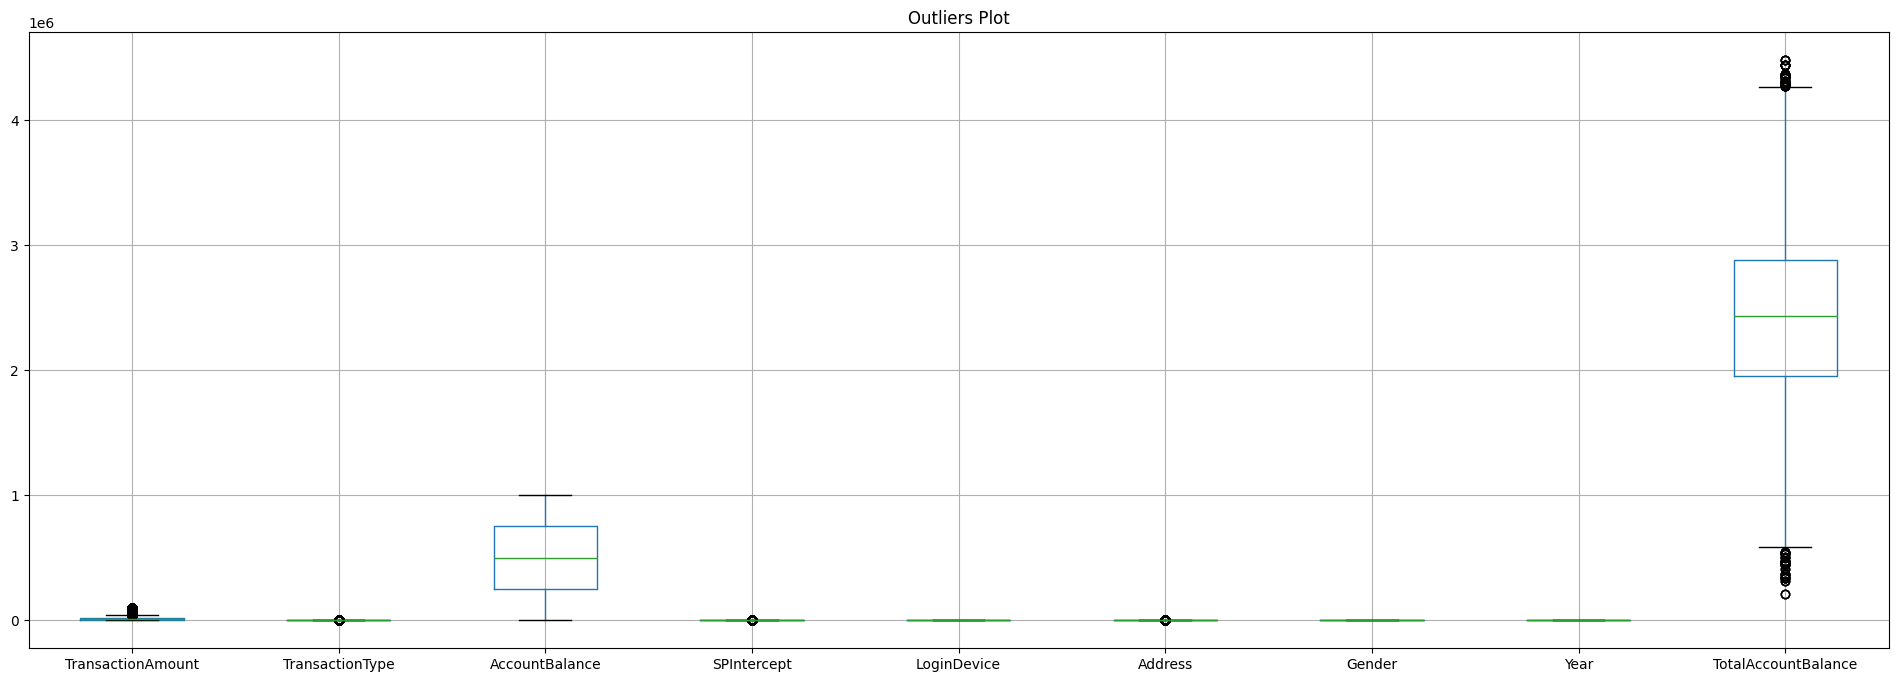

In [192]:
plt.figure(figsize=(24,8))
plt.title("Outliers Plot")
merged_df.boxplot()

In [193]:
#IQR method

Q1 = merged_df.quantile(0.25)
Q3 = merged_df.quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
filtered_df = merged_df[~((merged_df < lower_bound) | (merged_df > upper_bound)).any(axis=1)]


<Axes: title={'center': 'Outliers Plot'}>

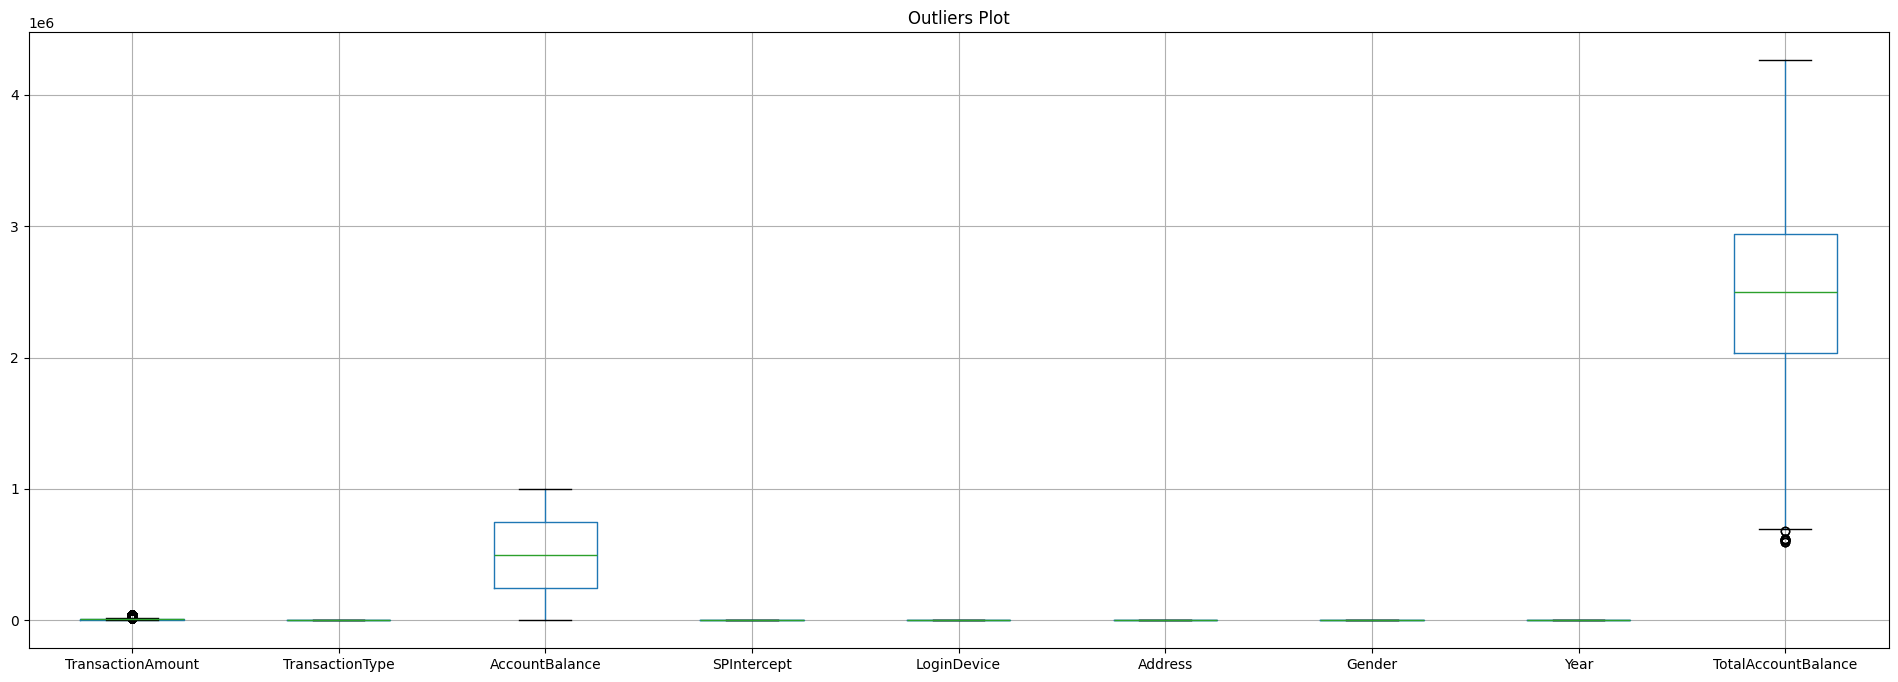

In [194]:
plt.figure(figsize=(24,8))
plt.title("Outliers Plot")
filtered_df.boxplot()

In [195]:
# Get unique values for the entire DataFrame
unique_values_per_row = merged_df.apply(lambda x: x.unique())
unique_values_per_row

TransactionAmount      [8790.43, 7158.76, 61284.18, 8244.07, 1221.55,...
TransactionType        [0.3782712133227597, 0.24200370076658737, 0.37...
AccountBalance         [176954.23, 159414.04, 998831.12, 297781.36, 7...
SPIntercept                                                       [0, 1]
LoginDevice            [0.2477531060005287, 0.25310600052868093, 0.24...
Address                [0.00011014186271918231, 8.811349017534584e-05...
Gender                                                            [0, 1]
Year                   [1972, 2014, 1959, 1940, 1967, 1989, 1932, 197...
TotalAccountBalance    [2424448.09, 2684403.4, 1472198.35, 2559678.96...
dtype: object

In [196]:
# #Robust Scaling

# from sklearn.preprocessing import RobustScaler

# scaler = RobustScaler()

# # Select the features you want to scale
# features_to_scale = ['TotalAccountBalance', 'AccountBalance','Year','TransactionAmount']

# # Fit and transform the selected features
# merged_df[features_to_scale] = scaler.fit_transform(merged_df[features_to_scale])

<Axes: title={'center': 'Outliers Plot'}>

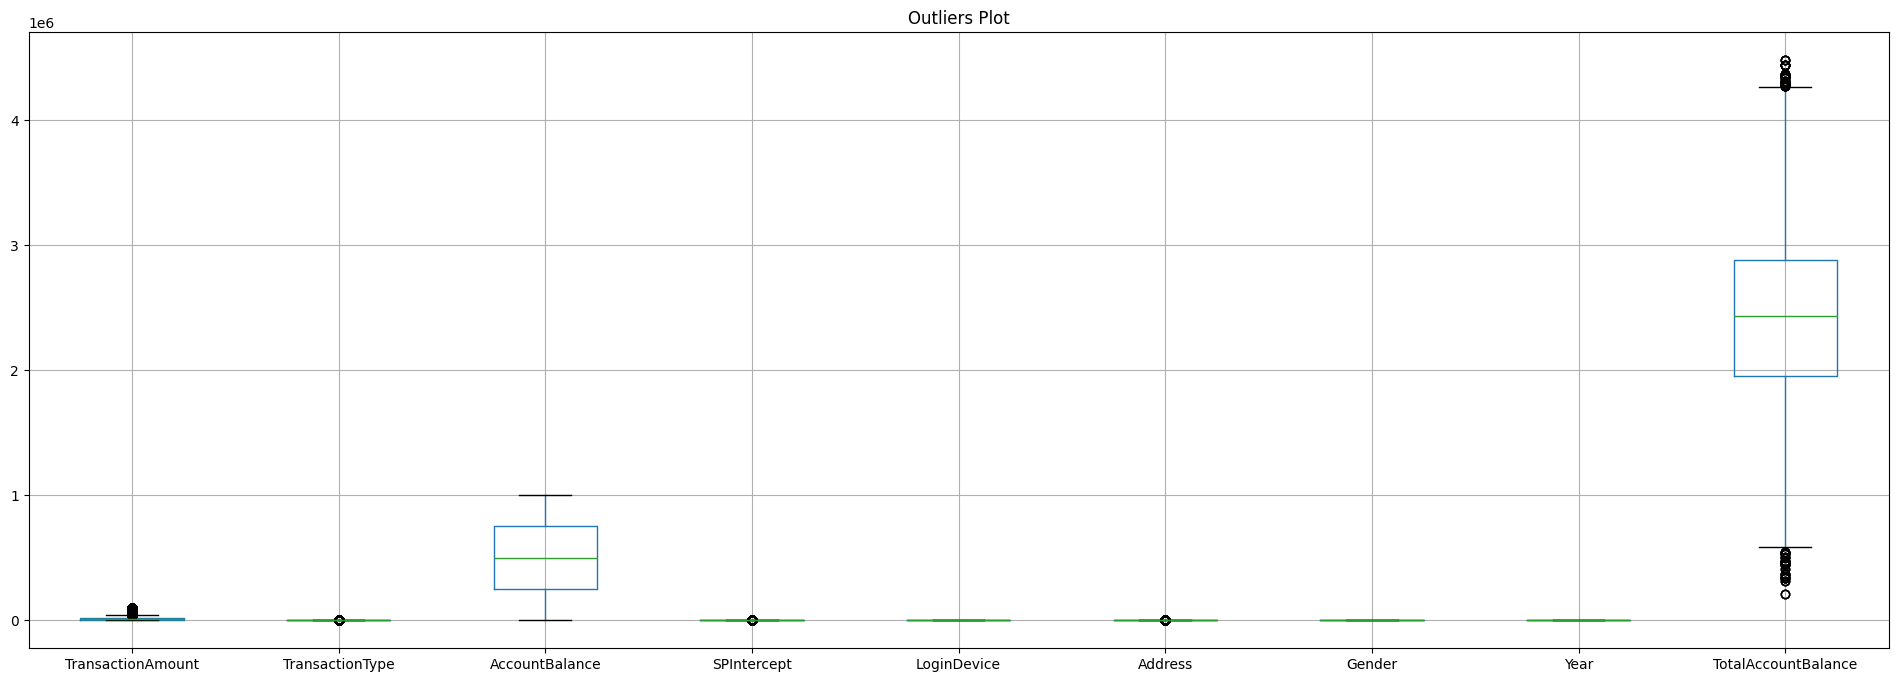

In [197]:
plt.figure(figsize=(24,8))
plt.title("Outliers Plot")
merged_df.boxplot()

Feature Selection

In [198]:
merged_df


,TransactionAmount,TransactionType,AccountBalance,SPIntercept,LoginDevice,Address,Gender,Year,TotalAccountBalance
0,8790.43,0.378271,176954.23,0,0.247753,0.00011,0,1972,2424448.09
1,7158.76,0.242004,159414.04,1,0.247753,0.00011,0,1972,2424448.09
2,61284.18,0.379725,998831.12,0,0.253106,0.00011,0,1972,2424448.09
3,8244.07,0.379725,297781.36,0,0.248458,0.00011,0,1972,2424448.09
4,1221.55,0.378271,791467.34,0,0.250683,0.00011,0,1972,2424448.09
...,...,...,...,...,...,...,...,...,...
45391,8169.44,0.242004,437970.50,0,0.250683,0.00011,1,1913,2608447.14
45392,80673.47,0.378271,9824.86,0,0.247753,0.00011,1,1913,2608447.14
45393,3370.36,0.242004,536494.57,0,0.247753,0.00011,1,1913,2608447.14
45394,21540.62,0.378271,810778.90,1,0.248458,0.00011,1,1913,2608447.14


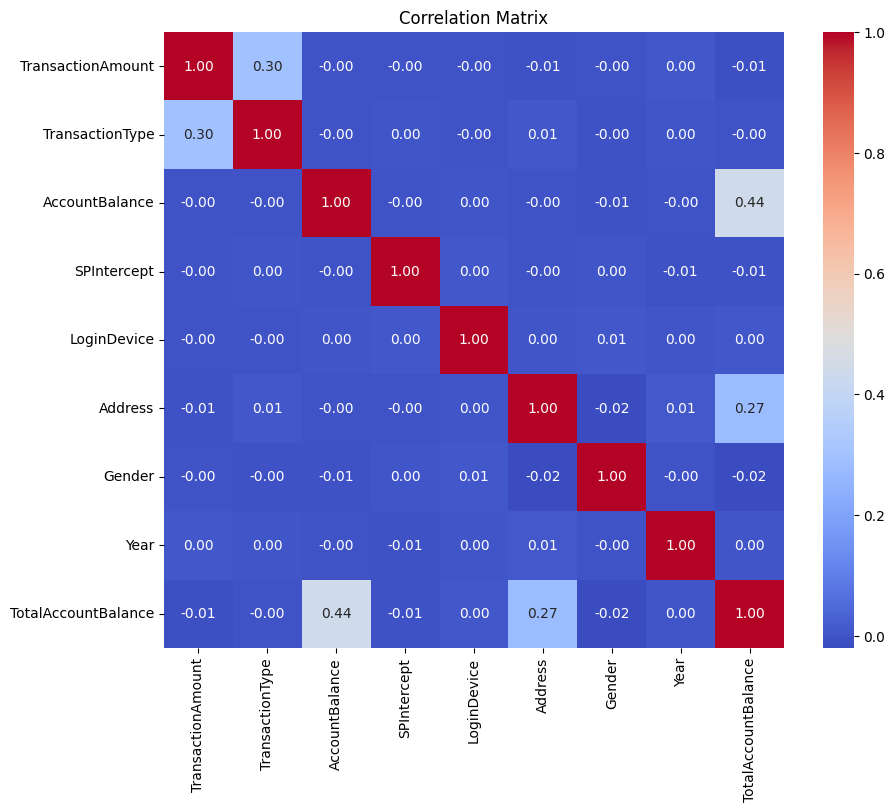

In [199]:

# Compute correlation matrix
corr_matrix = merged_df.corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# Remove highly correlated features (e.g., above 0.9 correlation)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column].abs() > 0.9)]

# Drop selected features
merged_df = merged_df.drop(columns=to_drop)


Feature Selection

In [202]:
from sklearn.decomposition import PCA

# Initialize PCA, specify the number of components (e.g., 2 components)
pca = PCA(n_components=2)

# Fit and transform the data
pca_result = pca.fit_transform(filtered_df)

# Access the explained variance ratio for each principal component
print(pca.explained_variance_ratio_)


[0.8729809  0.12688221]


In [204]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=3)
kmeans.fit(filtered_df)

# After clustering, assess feature importance
silhouette_avg = silhouette_score(filtered_df, kmeans.labels_)
print("The average silhouette_score is :", silhouette_avg)


The average silhouette_score is : 0.3914375235543986
